In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================
# Load datasets
# ============================================
train_df = pd.read_csv(r"C:\Users\sheri\Desktop\machinlearning\data\raw_data\train.csv")
eval_df = pd.read_csv(r"C:\Users\sheri\Desktop\machinlearning\data\raw_data\eval.csv")
holdout_df = pd.read_csv(r"C:\Users\sheri\Desktop\machinlearning\data\raw_data\holdout.csv")

pd.set_option('display.max_columns', None)    # Show all columns in the DataFrame
pd.set_option('display.max_rows', None)      # Show all rows in the DataFrame

In [26]:
print(train_df.shape)
print(eval_df.shape)

(63535, 2)
(35058, 2)


Check for Duplicates

In [27]:
print(train_df.shape)

duplicated_rows = train_df[train_df.duplicated()].shape[0]
print("Duplicated_ rows:", duplicated_rows)


#duplicated_rows = train_df[train_df.duplicated(subset=train_df.columns.difference(['date', 'year']))].shape[0]
#print("Duplicated_row excluding date column:", duplicated_rows)

(63535, 2)
Duplicated_ rows: 0


In [40]:
print(eval_df.shape)

duplicated_rows = eval_df[eval_df.duplicated()].shape[0]
print("Duplicated_ rows:", duplicated_rows)

(34923, 2)
Duplicated_ rows: 0


In [41]:
print(holdout_df.shape)

duplicated_rows = holdout_df[holdout_df.duplicated()].shape[0]
print("Duplicated_ rows:", duplicated_rows)

(22670, 2)
Duplicated_ rows: 0


In [28]:
# Delete duplicates if any
#train_df = train_df.drop_duplicates(subset=train_df.columns.difference(['date', 'year']), keep=False)
#print(train_df.shape)

#duplicated_rows = train_df[train_df.duplicated()].shape[0]
#print("Duplicated_rows:", duplicated_rows)

#duplicated_rows = train_df[train_df.drop_duplicates(subset=train_df.columns.difference(['date', 'year']))].shape[0]
#print("duplicated_rows excluding date column:", duplicated_rows)

# Repeat for eval date

Check for Outliers and cleaning

In [29]:
train_df['AEP_MW'].describe()

count    63535.000000
mean     15949.632769
std       2588.539364
min       9701.000000
25%      14086.000000
50%      15758.000000
75%      17634.000000
max      25695.000000
Name: AEP_MW, dtype: float64

In [30]:
import plotly.express as px

fig = px.violin(train_df, y = "AEP_MW", box=True, hover_name="AEP_MW")
fig.update_layout(title = "Violin Plot of AEP_MW")
fig.show()

In [31]:
# Boxplot
#fig = plt.figure(figsize =(10, 7))

#plt.boxplot(train_df['AEP_MW'])
#plt.show()

In [32]:
top_1_percent = train_df.nlargest(int(0.01 * len(train_df)), 'AEP_MW')
print(top_1_percent.shape)
top_1_percent.head(10)

(635, 2)


,Datetime,AEP_MW
35525,2008-10-20 14:00:00,25695.0
24992,2007-08-08 15:00:00,25164.0
24994,2007-08-08 17:00:00,25140.0
24993,2007-08-08 16:00:00,25056.0
25018,2007-08-09 17:00:00,25035.0
25017,2007-08-09 16:00:00,24978.0
24991,2007-08-08 14:00:00,24941.0
25016,2007-08-09 15:00:00,24911.0
24995,2007-08-08 18:00:00,24878.0
25354,2007-08-23 17:00:00,24862.0


In [33]:
top_1_percent = train_df.nlargest(int(0.01 * len(train_df)), 'AEP_MW')
print(top_1_percent['AEP_MW'].value_counts().sort_index(ascending=False))

AEP_MW
25695.0    1
25164.0    1
25140.0    1
25056.0    1
25035.0    1
24978.0    1
24941.0    1
24911.0    1
24878.0    1
24862.0    1
24842.0    1
24828.0    1
24811.0    1
24741.0    1
24736.0    1
24712.0    1
24711.0    1
24703.0    1
24696.0    1
24679.0    1
24642.0    1
24639.0    1
24632.0    1
24629.0    1
24611.0    1
24602.0    1
24597.0    1
24586.0    1
24555.0    1
24538.0    1
24505.0    1
24490.0    1
24480.0    1
24475.0    1
24465.0    1
24462.0    1
24435.0    1
24426.0    1
24423.0    1
24420.0    1
24413.0    1
24409.0    2
24367.0    1
24356.0    1
24352.0    1
24342.0    1
24330.0    1
24316.0    1
24311.0    1
24291.0    1
24274.0    1
24273.0    1
24270.0    1
24242.0    1
24235.0    2
24204.0    1
24184.0    1
24134.0    1
24113.0    1
24104.0    1
24082.0    1
24065.0    1
24045.0    1
24044.0    1
24038.0    1
24020.0    1
24017.0    1
24015.0    1
24004.0    1
23975.0    2
23970.0    1
23965.0    1
23964.0    1
23963.0    1
23945.0    1
23940.0    1
23938

In [34]:
# Drop/clean the outliers above 22450 value
train_df = train_df[train_df['AEP_MW'] <= 22450].copy()
eval_df = eval_df[eval_df['AEP_MW'] <= 22450].copy()
holdout_df = holdout_df[holdout_df['AEP_MW'] <= 22450].copy()

In [35]:
fig = px.violin(train_df, y = "AEP_MW", box=True, hover_name="AEP_MW")
fig.update_layout(title = "Violin Plot of AEP_MW")
fig.show()

In [42]:
# =========================================
# Save cleaned datasets
# =========================================
train_df.to_csv(r'C:\Users\sheri\Desktop\machinlearning\data\processed_data\cleaned_train.csv', index=False)
eval_df.to_csv(r'C:\Users\sheri\Desktop\machinlearning\data\processed_data\cleaned_eval.csv', index=False)
holdout_df.to_csv(r'C:\Users\sheri\Desktop\machinlearning\data\processed_data\cleaned_holdout.csv', index=False)

print("cleaning complete.")

cleaning complete.


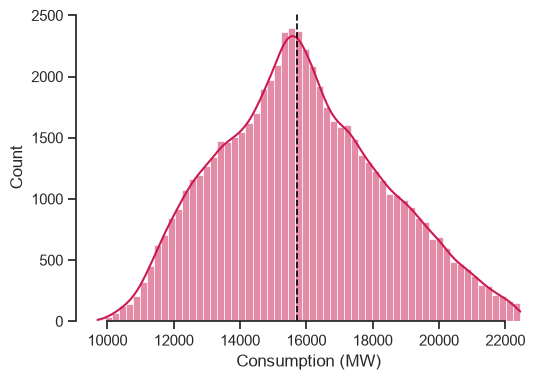

In [37]:
# Distribution of hourly energy consumption
df = train_df
sns.set_theme(style="ticks")
fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(df['AEP_MW'].dropna(), bins=60, kde=True, color=sns.color_palette("rocket_r", 1)[0], ax=ax)
median_AEP_MW = df['AEP_MW'].median()
ax.axvline(median_AEP_MW, ls="--", lw=1.2, color="black")
ax.set_xlabel("Consumption (MW)")
ax.set_ylabel("Count")
sns.despine(trim=True)
ax.grid(False)
ax.ticklabel_format(axis="x", style="plain")
plt.show()

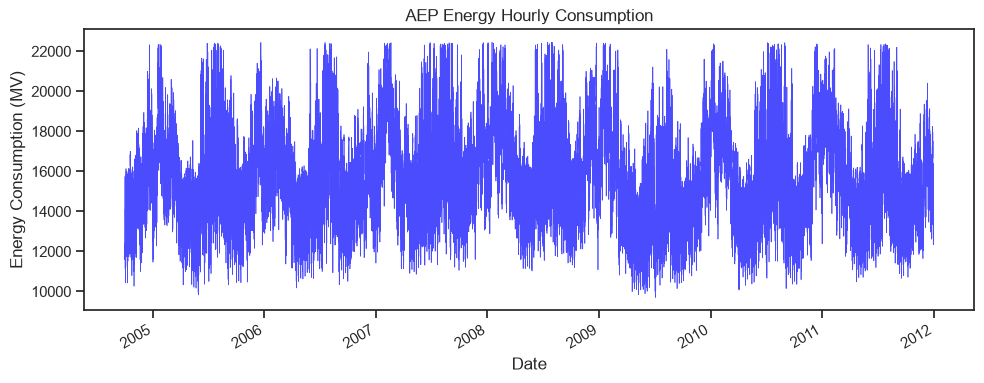

In [38]:
# AEP Hourly Consumption
# Datetime is a datetime type
df["Datetime"] = pd.to_datetime(df["Datetime"])

# Set Datetime as the index
df = df.set_index("Datetime")

fig, ax = plt.subplots(figsize=(10,4))
df['AEP_MW'].plot(ax=ax, color='blue', linewidth=0.5,alpha=0.7)
#(pd.to_datetime(df['AEP_MW'])).plot(ax=ax, color='blue', linewidth=0.5,alpha=0.7)
ax.set_title('AEP Energy Hourly Consumption', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Energy Consumption (MV)')
plt.tight_layout()
plt.show()

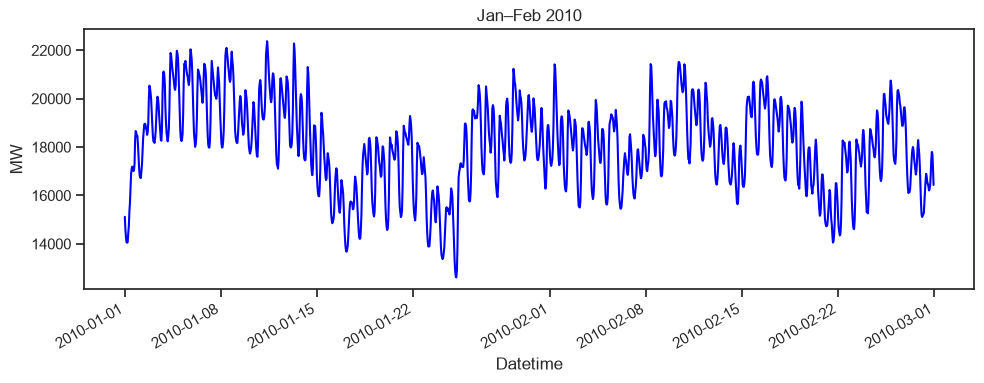

In [39]:
# Plot weekly and daily seasonality, that we expect
df['AEP_MW']['2010-01':'2010-02'].plot(figsize=(10, 4), title='Jan–Feb 2010', color='blue')
plt.ylabel('MW')
plt.tight_layout()
plt.show()